# COMP90089 Assignment 2

Student ID: 1750041

Name: Ya-Chu Yang

### Access MIMIC via Google Bigquery

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from pandas_gbq import read_gbq


project_id = 'my-project-mlh-506211'

HOSP    = 'physionet-data.mimiciv_3_1_hosp'
ICU     = 'physionet-data.mimiciv_3_1_icu'
DERIVED = 'physionet-data.mimiciv_3_1_derived'


def run_query(query, project_id=project_id):
    return read_gbq(query, project_id=project_id, dialect='standard')


print("Connected to project:", project_id)

Connected to project: my-project-mlh-506211


### Step 1. Build the sepsis cohort

In [2]:
# inspect sepsis3 table
q_explore = f"""
SELECT *
FROM `{DERIVED}.sepsis3`
LIMIT 20
"""
df_explore = run_query(q_explore)
print(df_explore.dtypes)   
# df_explore.head()

Downloading: 100%|██████████|
subject_id                           Int64
stay_id                              Int64
antibiotic_time             datetime64[us]
culture_time                datetime64[us]
suspected_infection_time    datetime64[us]
sofa_time                   datetime64[us]
sofa_score                           Int64
respiration                          Int64
coagulation                          Int64
liver                                Int64
cardiovascular                       Int64
cns                                  Int64
renal                                Int64
sepsis3                            boolean
dtype: object


- sofa_time set as time 0
- no hadm_id: need to link stay_id to hadm_id

In [3]:
# check the structure and content of the sepsis3 table
q_check = f"""
SELECT 
    COUNT(*) AS n_rows,
    COUNT(DISTINCT stay_id) AS n_stays,
    COUNT(DISTINCT subject_id) AS n_subjects,
    COUNTIF(sepsis3) AS n_sepsis3_true,
    COUNTIF(sofa_time IS NULL) AS n_null_sofa_time
FROM `{DERIVED}.sepsis3`
"""

run_query(q_check)

Downloading: 100%|██████████|


,n_rows,n_stays,n_subjects,n_sepsis3_true,n_null_sofa_time
0,32899,32899,25570,32899,0


- no duplicate ICU stays and all patients are sepsis: no need to add WHERE sepsis3 to filter
- 32899-25570 = 7329: there are 7329 sepsis episodes occur on same patients during their multiple ICU stays
- null_sofa_time = 0: every rows can set as t0
- need to exclude the 7329 multiple episodes, only include the first episodes


In [4]:
# define the cohort of sepsis patients
CTE_COHORT = f"""
WITH sepsis_ranked AS (
    SELECT
        s.subject_id,
        s.stay_id,
        s.sofa_time AS t0,
        s.sofa_score,
        s.respiration,
        s.coagulation,
        s.liver,
        s.cardiovascular,
        s.cns,
        s.renal,
        s.suspected_infection_time,
        p.anchor_age,
        p.gender,
        ROW_NUMBER() OVER (
            PARTITION BY s.subject_id
            ORDER BY s.sofa_time, s.stay_id
        ) AS order_no
    FROM `{DERIVED}.sepsis3` s
    INNER JOIN `{HOSP}.patients` p
    ON s.subject_id = p.subject_id
    WHERE p.anchor_age >= 18

),
cohort AS (
    SELECT *
    FROM sepsis_ranked
    WHERE order_no = 1
)
"""

df_cohort = run_query(CTE_COHORT + "SELECT * FROM cohort")
print("Cohort size:", df_cohort.shape)
# recheck every subject only appear once
assert df_cohort['subject_id'].is_unique, "Has duplicate patients."
print("Patients retained:", len(df_cohort), "of 25570 sepsis patients.")
# df_cohort.head()

Downloading: 100%|██████████|
Cohort size: (25570, 14)
Patients retained: 25570 of 25570 sepsis patients.


anchor_age >= 18 did not exclude any patients since all patients in MIMIC are adults.

### Build outcome table ( in-hospital mortality,ICU LOS, and hospital LOS.)

In [5]:
# define the outcome table
q_outcome = CTE_COHORT + f"""
SELECT 
    c.subject_id,
    c.stay_id,
    i.hadm_id,
    i.los AS icu_los_days,
    a.hospital_expire_flag AS in_hospital_mortality,
    DATETIME_DIFF(a.dischtime, a.admittime, MINUTE) / 1440 AS hospital_los_days
    
FROM cohort c
LEFT JOIN `{ICU}.icustays` i
ON c.stay_id = i.stay_id
LEFT JOIN `{HOSP}.admissions` a
ON i.hadm_id = a.hadm_id
"""

df_outcome = run_query(q_outcome)
assert len(df_outcome) == len(df_cohort), f"Outcome table rows: {len(df_outcome)}"
assert df_outcome['stay_id'].is_unique, "Duplicate stay in outcome table."
print("Outcome table:", df_outcome.shape)
# check for missing values
print(df_outcome.isna().sum())
# df_outcome.head()

Downloading: 100%|██████████|
Outcome table: (25570, 6)
subject_id               0
stay_id                  0
hadm_id                  0
icu_los_days             0
in_hospital_mortality    0
hospital_los_days        0
dtype: int64


In [6]:
# sanity check: in-hospital mortality rate and LOS
print(f"In-hospital mortality rate: {df_outcome['in_hospital_mortality'].mean():.1%}")
print("Hospital LOS shorter than ICU LOS:",
      (df_outcome['hospital_los_days'] < df_outcome['icu_los_days']).sum())
df_outcome[['icu_los_days', 'hospital_los_days']].describe()

In-hospital mortality rate: 15.8%
Hospital LOS shorter than ICU LOS: 2237


,icu_los_days,hospital_los_days
count,25570.000000,25570.000000
mean,5.112501,12.358891
std,6.514429,12.680063
min,0.081979,-0.779861
25%,1.486661,5.086111
50%,2.841597,8.455556
75%,5.922280,15.070486
max,101.726238,249.585417


Problems found:
- 2237 rows hospital LOS < ICU LOS
- hospital LOS min = −0.78, patients' discharge time earlier than admission time

In [7]:
# check number of circumstances in hospital LOS < ICU LOS
q_problem = CTE_COHORT + f"""
SELECT
    COUNTIF(a.dischtime < a.admittime) AS n_negative_hosp_los,
    COUNTIF(i.intime < a.admittime) AS n_icu_in_before_admit,
    COUNTIF(i.outtime > a.dischtime) AS n_icu_out_after_discharge
FROM cohort c
LEFT JOIN `{ICU}.icustays` i
ON c.stay_id = i.stay_id
LEFT JOIN `{HOSP}.admissions` a
ON i.hadm_id = a.hadm_id
"""
run_query(q_problem)



Downloading: 100%|██████████|


,n_negative_hosp_los,n_icu_in_before_admit,n_icu_out_after_discharge
0,20,326,4409


In [8]:
# check the gap between ICU LOS and hospital LOS
gap_h = (df_outcome['icu_los_days'] - df_outcome['hospital_los_days']) * 24
gap_h[gap_h > 0].describe()

count    2237.000000
mean        5.751646
std        13.417570
min         0.001389
25%         0.825000
50%         1.996389
75%         3.786667
max       377.044167
dtype: float64

**Outcome data quality checks**
- **Negative hospital LOS (n = 20):** `dischtime` earlier than `admittime` is impossible and treated as recording error. Hospital LOS was set to NaN for these stays. Patients kept in cohort, as only this outcome value is affected.
- **Hospital LOS shorter than ICU LOS (n = 2,237, 8.7%):** mainly because ICU `outtime` was recorded
  after hospital `dischtime` (4,409 stays), plausibly reflecting administrative discharge being recorded
  before the patient physically left the unit.
- **Magnitude is small:** among the 2,237 stays, the median discrepancy was 2.0 hours (75th percentile
  3.8 hours). As hospital LOS is an outcome rather than a clustering feature, these values were retained.

In [9]:
# negative hospital LOS assumed to be recording error: decide to set to NaN (patients kept)
neg = df_outcome['hospital_los_days'] < 0
df_outcome.loc[neg, 'hospital_los_days'] = np.nan
print("Hospital LOS set to NaN:", neg.sum())

Hospital LOS set to NaN: 20


In [10]:
# merge cohort and outcome tables
d = df_cohort.merge(
    df_outcome[['stay_id', 'in_hospital_mortality', 'icu_los_days', 'hospital_los_days']],
    on='stay_id', how='left'
)
# define functions for summarizing data
def med_iqr(s):
    q = s.astype(float).quantile([0.25, 0.5, 0.75])
    return f"{q[0.5]:.1f} ({q[0.25]:.1f}–{q[0.75]:.1f})"
# function to calculate count and percentage
def n_pct(mask):
    return f"{int(mask.sum()):,} ({mask.mean():.1%})"

summary = pd.Series({
    'Patients, n': f"{len(d):,}",
    'Age, median (IQR)': med_iqr(d['anchor_age']),
    'Male, n (%)': n_pct(d['gender'] == 'M'),
    'SOFA score, median (IQR)': med_iqr(d['sofa_score']),
    'In-hospital mortality, n (%)': n_pct(d['in_hospital_mortality'] == 1),
    'ICU LOS (days), median (IQR)': med_iqr(d['icu_los_days']),
    'Hospital LOS (days), median (IQR)': med_iqr(d['hospital_los_days']),
})
display(summary.to_frame('Sepsis cohort'))

,Sepsis cohort
"Patients, n","25,570"
"Age, median (IQR)",67.0 (55.0–77.0)
"Male, n (%)","14,743 (57.7%)"
"SOFA score, median (IQR)",3.0 (2.0–4.0)
"In-hospital mortality, n (%)","4,030 (15.8%)"
"ICU LOS (days), median (IQR)",2.8 (1.5–5.9)
"Hospital LOS (days), median (IQR)",8.5 (5.1–15.1)


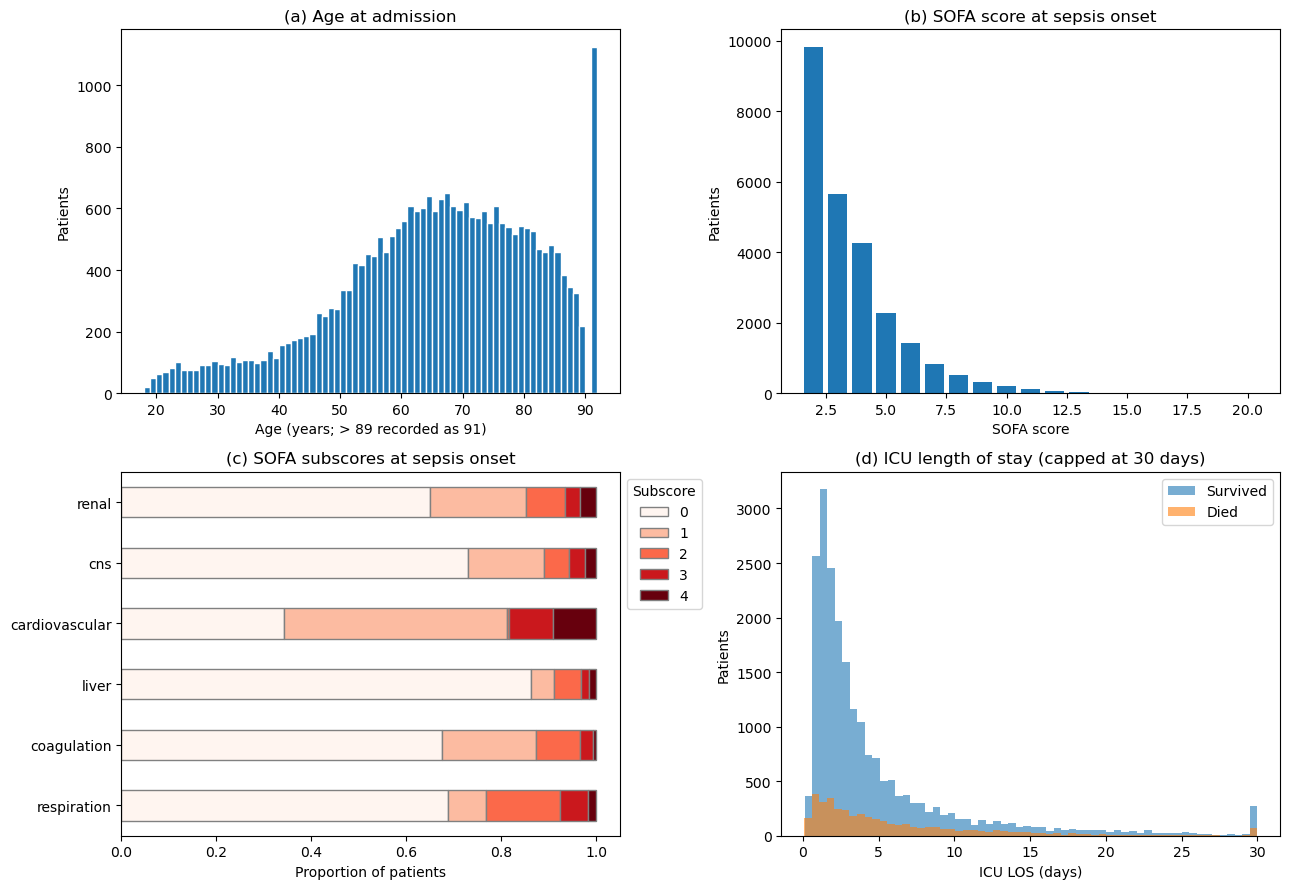

In [11]:
# plot the distributions of age, SOFA score, SOFA subscores, and ICU LOS
SUBS = ['respiration', 'coagulation', 'liver', 'cardiovascular', 'cns', 'renal']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) age distribution
axes[0, 0].hist(d['anchor_age'].astype(float), bins=range(18, 93), edgecolor='white')
axes[0, 0].set_title('(a) Age at admission')
axes[0, 0].set_xlabel('Age (years; > 89 recorded as 91)')
axes[0, 0].set_ylabel('Patients')

# (b) SOFA score distribution
sofa_counts = d['sofa_score'].astype(int).value_counts().sort_index()
axes[0, 1].bar(sofa_counts.index, sofa_counts.values)
axes[0, 1].set_title('(b) SOFA score at sepsis onset')
axes[0, 1].set_xlabel('SOFA score')
axes[0, 1].set_ylabel('Patients')

# (c) SOFA subscores distribution
sub_dist = (d[SUBS].astype(int)
            .apply(lambda s: s.value_counts(normalize=True))
            .T.reindex(columns=[0, 1, 2, 3, 4]).fillna(0))
sub_dist.plot(kind='barh', stacked=True, colormap='Reds', ax=axes[1, 0], edgecolor='grey')
axes[1, 0].set_title('(c) SOFA subscores at sepsis onset')
axes[1, 0].set_xlabel('Proportion of patients')
axes[1, 0].legend(title='Subscore', bbox_to_anchor=(1, 1))

# (d) ICU LOS distribution, divided from survived and died patients group
los = d['icu_los_days'].astype(float).clip(upper=30)
for flag, label in [(0, 'Survived'), (1, 'Died')]:
    axes[1, 1].hist(los[d['in_hospital_mortality'] == flag], bins=60, alpha=0.6, label=label)
axes[1, 1].set_title('(d) ICU length of stay (capped at 30 days)')
axes[1, 1].set_xlabel('ICU LOS (days)')
axes[1, 1].set_ylabel('Patients')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## **Q1. Sepsis cohort summary (from plots and summary table)**

The cohort includes 25,570 adult patients, using each patient's first Sepsis-3 ICU episode. Among them, 11 were no longer in the ICU at sepsis onset (t0), so 25,559 patients were used for k-means clustering.

*Demographics (plot a)*
The median age was 67 years (IQR 55–77), and 57.7% of patients were male according to the summary table. The spike at 91 in plot (a) reflects MIMIC-IV de-identification results as all ages above 89 are recorded as 91.

*Severity at sepsis onset (plots b, c)*
The median SOFA score was 3 (IQR 2–4), with a right-skewed distribution starting at 2. Cardiovascular dysfunction was the most common (66% with subscore > 0), and most of them had a subscore of 1. Renal dysfunction (35%) was the next most frequent, while the liver was the least affected organ (14%).

*Outcomes (plot d)*
In-hospital mortality was 15.8% (4,030 patients) from the summary table. The median ICU length of stay was 2.8 days (IQR 1.5–5.9) and the median hospital length of stay was 8.5 days (IQR 5.1–15.1). ICU length of stay was strongly right-skewed in both groups. However, the survived group is concentrated at 1–3 days and the died group spreads across the whole range.


### Step 2. Build the 24-hour windows

In [12]:
# build Window 0-3 for every patients
N_WINDOWS = 4
CTE_WINDOWS = CTE_COHORT + f""",
windows AS (
    SELECT 
        c.subject_id,
        c.stay_id,
        c.t0,
        w AS window_no,
        DATETIME_ADD(c.t0, INTERVAL 24 * w HOUR) AS win_start,
        DATETIME_ADD(c.t0, INTERVAL 24 * (w+1) HOUR) AS win_end
    FROM cohort c
    CROSS JOIN UNNEST(GENERATE_ARRAY(0, {N_WINDOWS - 1})) AS w

)
"""

df_windows = run_query(CTE_WINDOWS + "SELECT * FROM windows ORDER BY stay_id, window_no")
assert len(df_windows) == len(df_cohort)* N_WINDOWS, f"Window table rows: {len(df_windows)}"
assert (df_windows.groupby('stay_id').size() == N_WINDOWS).all(), "Some patients do not have 4 windows."
assert ((df_windows['win_end'] - df_windows['win_start']) == pd.Timedelta(hours=24)).all(), "Some windows are not 24 hours."
print(df_windows.shape)
# df_windows.head()

Downloading: 100%|██████████|
(102280, 6)


- Note: SOFA in sepsis3 in updated on hourly basis.

In [13]:
# check the number of patients who died in hospital but have no deathtime recorded
q_dt = CTE_COHORT + f"""
SELECT COUNTIF(a.hospital_expire_flag = 1 AND a.deathtime IS NULL) AS n_died_no_deathtime
FROM cohort c
LEFT JOIN `{ICU}.icustays` i ON c.stay_id = i.stay_id
LEFT JOIN `{HOSP}.admissions` a ON i.hadm_id = a.hadm_id
"""
run_query(q_dt)

Downloading: 100%|██████████|


,n_died_no_deathtime
0,4


4 patients died in hospital but did not have death time recorded.
- use COALESCE(a.deathtime, a.dischtime) to assign `dischtime` as replacement.

In [14]:
# mark patient's status in each window into 3 groups: 1. in_icu 2. died 3. out_icu
CTE_STATUS = CTE_WINDOWS + f""",
pt_status AS (
    SELECT
        w.*,
        i.outtime,
        
        CASE 
            WHEN a.hospital_expire_flag = 1 
                THEN COALESCE(a.deathtime,a.dischtime) 
        END AS death_time,
        CASE
            WHEN COALESCE(a.deathtime,a.dischtime) <= win_start 
            AND a.hospital_expire_flag = 1
                THEN 'died'
            WHEN i.outtime <= win_start 
                THEN 'out_icu'
            ELSE 'in_icu'
        END AS status
    FROM windows w
    LEFT JOIN `{ICU}.icustays` i
    ON w.stay_id = i.stay_id
    LEFT JOIN `{HOSP}.admissions` a
    ON i.hadm_id = a.hadm_id
)
"""

df_status = run_query(CTE_STATUS + "SELECT * FROM pt_status ORDER BY stay_id, window_no")
print(df_status.shape)
status_table = pd.crosstab(df_status['window_no'], df_status['status'])
print(status_table)

assert status_table['died'].is_monotonic_increasing, "Died count decreased across windows."
assert status_table['in_icu'].is_monotonic_decreasing, "In-ICU count increased across windows."
# df_status.head()

Downloading: 100%|██████████|
(102280, 9)
status     died  in_icu  out_icu
window_no                       
0             7   25559        4
1           531   21407     3632
2          1000   15332     9238
3          1334   11395    12841


### Step 3. The organ-dysfunction variables

In [15]:
# check all table names from deriveed schema
q_tables = f"""
SELECT table_name
FROM `{DERIVED}.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
"""

derived_tables = run_query(q_tables)
print(derived_tables['table_name'].tolist())

Downloading: 100%|██████████|
['_metadata', 'acei', 'age', 'antibiotic', 'apsiii', 'arb', 'bg', 'blood_differential', 'cardiac_marker', 'charlson', 'chemistry', 'coagulation', 'code_status', 'complete_blood_count', 'creatinine_baseline', 'crrt', 'dobutamine', 'dopamine', 'enzyme', 'epinephrine', 'first_day_bg', 'first_day_bg_art', 'first_day_gcs', 'first_day_height', 'first_day_lab', 'first_day_rrt', 'first_day_sofa', 'first_day_urine_output', 'first_day_vitalsign', 'first_day_weight', 'gcs', 'height', 'icp', 'icustay_detail', 'icustay_hourly', 'icustay_times', 'inflammation', 'invasive_line', 'kdigo_creatinine', 'kdigo_stages', 'kdigo_uo', 'lods', 'meld', 'milrinone', 'neuroblock', 'norepinephrine', 'norepinephrine_equivalent_dose', 'nsaid', 'oasis', 'oxygen_delivery', 'phenylephrine', 'rhythm', 'rrt', 'sapsii', 'sepsis3', 'sirs', 'sofa', 'suspicion_of_infection', 'urine_output', 'urine_output_rate', 'vasoactive_agent', 'vasopressin', 'ventilation', 'ventilator_setting', 'vitalsign', 

In [16]:
needed = ['enzyme', 'coagulation', 'complete_blood_count', # liver, coag
          'bg', 'ventilation', # resp
          'chemistry', 'kdigo_stages', 'crrt', #renal
          'vasoactive_agent', 'norepinephrine_equivalent_dose', #cardio
          'gcs'] # neuro

# check if all needed tables are present in derived schema
missing = [t for t in needed if t not in derived_tables['table_name'].tolist()]
print("Missing tables:", missing)

Missing tables: []


In [17]:
# check columns name in all needed table to pick the required colums
q_cols = f"""
SELECT 
    table_name,
    column_name,
    data_type
FROM `{DERIVED}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name IN ('enzyme', 'coagulation', 'complete_blood_count', 
          'bg', 'ventilation', 
          'chemistry', 'kdigo_stages', 'crrt', 
          'vasoactive_agent', 'norepinephrine_equivalent_dose', 
          'gcs')
ORDER BY table_name, ordinal_position
"""
df_cols = run_query(q_cols)

for table, col in df_cols.groupby('table_name'):
    print(f"{table}: {col['column_name'].tolist()}")

Downloading: 100%|██████████|
bg: ['subject_id', 'hadm_id', 'charttime', 'specimen', 'so2', 'po2', 'pco2', 'fio2_chartevents', 'fio2', 'aado2', 'aado2_calc', 'pao2fio2ratio', 'ph', 'baseexcess', 'bicarbonate', 'totalco2', 'hematocrit', 'hemoglobin', 'carboxyhemoglobin', 'methemoglobin', 'chloride', 'calcium', 'temperature', 'potassium', 'sodium', 'lactate', 'glucose']
chemistry: ['subject_id', 'hadm_id', 'charttime', 'specimen_id', 'albumin', 'globulin', 'total_protein', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium']
coagulation: ['subject_id', 'hadm_id', 'charttime', 'specimen_id', 'd_dimer', 'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt']
complete_blood_count: ['subject_id', 'hadm_id', 'charttime', 'specimen_id', 'hematocrit', 'hemoglobin', 'mch', 'mchc', 'mcv', 'platelet', 'rbc', 'rdw', 'rdwsd', 'wbc']
crrt: ['stay_id', 'charttime', 'crrt_mode', 'access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_fluid', 'dia

- bg, chemistry, coagulation, complete_blood_count, enzyme table: use subject_id to join
- crrt, gcs, kdigo_stages, norepinephrine_equivalent_dose, vasoactive_agent, ventilation table: use stay_id to join

In [18]:
# function to check missing rate in each variable
def check_var(df_var, cols):
    # check rows missingness
    assert len(df_var) == len(df_windows), f"Row cont {len(df_var)} != {len(df_windows)}"
    assert not  df_var.duplicated(['stay_id', 'window_no']).any(), "Duplicated stay_id and window_no."
    print(df_var.shape)
    print("Missing rate of all patients:")
    print(df_var.groupby('window_no')[cols].apply(lambda s: s.isna().mean()))
    # check missing rate for in_icu pts only
    merged = df_var.merge(df_status[['stay_id', 'window_no', 'status']],
                          on = ['stay_id', 'window_no'])
    in_icu = merged[merged['status'] == 'in_icu']
    print("Missing rate of in-ICU patients:")
    print(in_icu.groupby('window_no')[cols].apply(lambda d: d.isna().mean()))

In [19]:
# function to run query for each variable table
def run_var(name):
    return run_query(CTE_WINDOWS + "," + VAR_CTES[name] + f"SELECT * FROM {name} ORDER BY stay_id, window_no")

In [20]:
# for plausible range and implausible counts storage
PLAUSIBLE = {}             
IMPLAUSIBLE_COUNTS = {}    
# function to describe the distribution of a variable and identify implausible values
def describe_var(df_var, col):
    print(df_var[col].describe([.001, .01, .5, .99, .999]).round(2))

# function to report the number of implausible values discarded for each variable
def report_implausible(df_var, name, n_col):
    n = int(df_var[n_col].sum())
    IMPLAUSIBLE_COUNTS[name] = n
    print(f"{name}: {n} implausible values discarded")

- **Plausibility ranges** 
  - Creatinine (0.1–60 mg/dL), total bilirubin (0.1–60 mg/dL), platelets (0–2000 K/uL) and GCS (3–15)
    follow the valid ranges in `variable_ranges.csv` of the MIMIC-III benchmark
    [1].
  - P/F ratio (30–700) was derived from the same file's limits for PaO2 (32–700 mmHg) and FiO2 (0.21–1.0).
  - INR, fibrinogen and norepinephrine-equivalent dose are not covered by that file. The ranges were
    set by clinical judgement.
- Source: https://github.com/YerevaNN/mimic3-benchmarks/blob/master/mimic3benchmark/resources/variable_ranges.csv

In [21]:
VAR_CTES = {}
# creatinine - chemistry: ['subject_id', 'charttime', 'creatinine']
# set plausible range for creatinine between 0.1-60 mg/dL
# 1. charttime within window [win_start, win_end) 
# 2. get creatinine MAX within window
# 3. nil value then use NULL (left join)
PLAUSIBLE['creatinine'] = (0.1, 60)    
lo, hi = PLAUSIBLE['creatinine']


VAR_CTES['creat'] = f"""
creat AS (
    SELECT
        w.stay_id,
        w.window_no,
        MAX
        (CASE 
            WHEN ch.creatinine BETWEEN {lo} AND {hi} 
                THEN ch.creatinine 
        END) AS creatinine_max,
        COUNTIF(ch.creatinine IS NOT NULL AND NOT ch.creatinine BETWEEN {lo} AND {hi}) AS creatinine_n_implausible
    FROM windows w
    LEFT JOIN `{DERIVED}.chemistry` ch
    ON ch.subject_id = w.subject_id
    AND ch.charttime >= w.win_start
    AND ch.charttime < w.win_end
    GROUP BY w.stay_id, w.window_no
)"""

df_creat = run_var('creat')
check_var(df_creat, ['creatinine_max'])
report_implausible(df_creat, 'creatinine', 'creatinine_n_implausible')
describe_var(df_creat, 'creatinine_max')    
# df_creat.head()

Downloading: 100%|██████████|
(102280, 4)
Missing rate of all patients:
           creatinine_max
window_no                
0                0.047595
1                0.083731
2                0.138326
3                0.211811
Missing rate of in-ICU patients:
           creatinine_max
window_no                
0                0.047459
1                0.056617
2                0.055896
3                0.059939
creatinine: 0 implausible values discarded
count    89969.00
mean         1.50
std          1.49
min          0.10
0.1%         0.20
1%           0.30
50%          1.00
99%          7.90
99.9%       13.10
max         32.30
Name: creatinine_max, dtype: float64


- Missingness that assessed only among patients still in the ICU at the start of each window showed Creatinine was missing in 4.7–6.0% of each windows. The higher missingness in later windows when all patients are included (up to 21.2% in window 3) reflects patients who had died or left the ICU.
- 0 implausible creatinine value is excluded. 

In [22]:
# bilirubin - enzyme: ['subject_id', 'charttime', 'bilirubin_total']
# set plausible range for bilirubin between 0.1-60 mg/dL
# 1. charttime within window [win_start, win_end) 
# 2. get bilirubin MAX within window
# 3. nil value then use NULL (left join)
PLAUSIBLE['bilirubin_total'] = (0.1, 60)    
lo, hi = PLAUSIBLE['bilirubin_total']

VAR_CTES['bili'] = f"""
bili AS (
    SELECT
        w.stay_id,
        w.window_no,
        MAX
        (CASE 
            WHEN e.bilirubin_total BETWEEN {lo} AND {hi}    
                THEN e.bilirubin_total 
        END) AS bilirubin_max,
        COUNTIF(e.bilirubin_total IS NOT NULL AND NOT e.bilirubin_total BETWEEN {lo} AND {hi})
            AS bilirubin_n_implausible
    FROM windows w
    LEFT JOIN `{DERIVED}.enzyme` e
    ON e.subject_id = w.subject_id
    AND e.charttime >= w.win_start
    AND e.charttime < w.win_end
    GROUP BY w.stay_id, w.window_no
)"""
df_bili = run_var('bili')
check_var(df_bili, ['bilirubin_max'])
report_implausible(df_bili, 'bilirubin_total', 'bilirubin_n_implausible')
describe_var(df_bili, 'bilirubin_max')
# df_bili.head()

Downloading: 100%|██████████|
(102280, 4)
Missing rate of all patients:
           bilirubin_max
window_no               
0               0.602542
1               0.679507
2               0.723074
3               0.760579
Missing rate of in-ICU patients:
           bilirubin_max
window_no               
0               0.602488
1               0.658336
2               0.663514
3               0.673717
bilirubin_total: 14 implausible values discarded
count    31561.00
mean         2.90
std          5.62
min          0.10
0.1%         0.10
1%           0.20
50%          1.00
99%         30.30
99.9%       51.49
max         59.10
Name: bilirubin_max, dtype: float64


- Missingness varied greatly by test: creatinine was missing in only 4.7% of window-0 patients,
whereas total bilirubin was missing in 60.2%. This reflects ordering practice rather than random
absence — routine biochemistry is measured daily, while liver function tests are ordered when
hepatic dysfunction is suspected.
- 14 implausible bilirubin values are excluded.

In [23]:
# INR - coagulation: ['subject_id', 'charttime', 'inr']
# set plausible range for INR 0.5–25 (clinical judgement, not in benchmark)
# 1. charttime within window [win_start, win_end)
# 2. get INR MAX within window
# 3. nil value then use NULL (left join)
PLAUSIBLE['inr'] = (0.5, 25)
lo, hi = PLAUSIBLE['inr']

VAR_CTES['inr'] = f"""
inr AS (
    SELECT
        w.stay_id,
        w.window_no,
        MAX
        (CASE
            WHEN co.inr BETWEEN {lo} AND {hi}
                THEN co.inr
        END) AS inr_max,
        COUNTIF(co.inr IS NOT NULL AND NOT co.inr BETWEEN {lo} AND {hi})
            AS inr_n_implausible
    FROM windows w
    LEFT JOIN `{DERIVED}.coagulation` co
    ON co.subject_id = w.subject_id
    AND co.charttime >= w.win_start
    AND co.charttime < w.win_end
    GROUP BY w.stay_id, w.window_no
)"""
df_inr = run_var('inr')
check_var(df_inr, ['inr_max'])
report_implausible(df_inr, 'inr', 'inr_n_implausible')
describe_var(df_inr, 'inr_max')
# df_inr.head()

Downloading: 100%|██████████|
(102280, 4)
Missing rate of all patients:
            inr_max
window_no          
0          0.292178
1          0.408330
2          0.490849
3          0.555886
Missing rate of in-ICU patients:
            inr_max
window_no          
0          0.292108
1          0.363292
2          0.366945
3          0.366740
inr: 0 implausible values discarded
count    57603.00
mean         1.58
std          0.92
min          0.70
0.1%         0.90
1%           0.90
50%          1.30
99%          5.40
99.9%       11.00
max         21.50
Name: inr_max, dtype: float64


- INR values above 20 have been reported in vitamin K antagonist poisoning [2]. Thus, the maximum value 21.5 is plausible.
- 0 implausible INR value is excluded. 

In [24]:
# fibrinogen - coagulation: ['subject_id', 'charttime', 'fibrinogen']
# set plausible range for fibrinogen 10–2000 mg/dL (clinical judgement, not in benchmark)
# 1. charttime within window [win_start, win_end)
# 2. get fibrinogen MIN within window (falls as coagulopathy worsens)
# 3. nil value then use NULL (left join)
PLAUSIBLE['fibrinogen'] = (10, 2000)
lo, hi = PLAUSIBLE['fibrinogen']

VAR_CTES['fib'] = f"""
fib AS (
    SELECT
        w.stay_id,
        w.window_no,
        MIN
        (CASE
            WHEN co.fibrinogen BETWEEN {lo} AND {hi}
                THEN co.fibrinogen
        END) AS fibrinogen_min,
        COUNTIF(co.fibrinogen IS NOT NULL AND NOT co.fibrinogen BETWEEN {lo} AND {hi})
            AS fibrinogen_n_implausible
    FROM windows w
    LEFT JOIN `{DERIVED}.coagulation` co
    ON co.subject_id = w.subject_id
    AND co.charttime >= w.win_start
    AND co.charttime < w.win_end
    GROUP BY w.stay_id, w.window_no
)"""
df_fib = run_var('fib')
check_var(df_fib, ['fibrinogen_min'])
report_implausible(df_fib, 'fibrinogen', 'fibrinogen_n_implausible')
describe_var(df_fib, 'fibrinogen_min')
# df_fib.head()

Downloading: 100%|██████████|
(102280, 4)
Missing rate of all patients:
           fibrinogen_min
window_no                
0                0.855338
1                0.913688
2                0.938365
3                0.955338
Missing rate of in-ICU patients:
           fibrinogen_min
window_no                
0                0.855393
1                0.901341
2                0.910188
3                0.919000
fibrinogen: 0 implausible values discarded
count    8624.00
mean      335.66
std       210.30
min        26.00
0.1%       37.00
1%         56.00
50%       280.00
99%       944.00
99.9%    1149.64
max      1709.00
Name: fibrinogen_min, dtype: float64


- Afibrinogenemia patients can have fibrinogen level lower than 10 [3]. The minimun value 26 is still plausible. 
- 0 implausible fibrinogen value is excluded. 

In [25]:
# platelets - complete_blood_count: ['subject_id', 'charttime', 'platelet']
# set plausible range for platelets 0–2000 K/uL (MIMIC-III benchmark)
# 1. charttime within window [win_start, win_end)
# 2. get platelets MIN within window (falls as coagulopathy worsens)
# 3. nil value then use NULL (left join)
PLAUSIBLE['platelet'] = (0, 2000)
lo, hi = PLAUSIBLE['platelet']

VAR_CTES['plt'] = f"""
plt AS (
    SELECT
        w.stay_id,
        w.window_no,
        MIN
        (CASE
            WHEN c.platelet BETWEEN {lo} AND {hi}
                THEN c.platelet
        END) AS platelets_min,
        COUNTIF(c.platelet IS NOT NULL AND NOT c.platelet BETWEEN {lo} AND {hi})
            AS platelets_n_implausible
    FROM windows w
    LEFT JOIN `{DERIVED}.complete_blood_count` c
    ON c.subject_id = w.subject_id
    AND c.charttime >= w.win_start
    AND c.charttime < w.win_end
    GROUP BY w.stay_id, w.window_no
)"""
df_plt = run_var('plt')
check_var(df_plt, ['platelets_min'])
report_implausible(df_plt, 'platelet', 'platelets_n_implausible')
describe_var(df_plt, 'platelets_min')
# df_plt.head()

Downloading: 100%|██████████|
(102280, 4)
Missing rate of all patients:
           platelets_min
window_no               
0               0.057333
1               0.088385
2               0.148181
3               0.229057
Missing rate of in-ICU patients:
           platelets_min
window_no               
0               0.057162
1               0.061756
2               0.063005
3               0.069329
platelet: 0 implausible values discarded
count    88908.00
mean       182.31
std        106.57
min          5.00
0.1%         7.00
1%          20.00
50%        164.00
99%        542.93
99.9%      817.09
max       1783.00
Name: platelets_min, dtype: float64


- 0 implausible platelet value is excluded. 

In [26]:
# check specimen type in bg table
run_query(f"""
SELECT 
    specimen,
    COUNT(*) AS n,
    COUNTIF(pao2fio2ratio IS NOT NULL) AS n_with_pf
FROM `{DERIVED}.bg`
GROUP BY specimen
ORDER BY n DESC
""")

Downloading: 100%|██████████|


,specimen,n,n_with_pf
0,ART.,514948,336998
1,VEN.,141822,36809
2,MIX.,15280,6031
3,None,14596,2262
4,CENTRAL VENOUS.,10772,5755


- `pao2fio2ratio` includes 36,809 venous and 5,755 central venous samples. 
- P/F ratio will always be lower in vein than arterty and the P/F ratio is only clinically interpretable for arterial blood, so only `specimen = 'ART.'` was included when getting minimum.

In [27]:
# PaO2/FiO2 ratio - bg: ['subject_id', 'charttime', 'specimen', 'pao2fio2ratio']
# set plausible range for P/F 30–700 (derived from benchmark PaO2 32–700 mmHg, FiO2 0.21–1.0)
# 1. charttime within window [win_start, win_end), arterial samples only
# 2. get P/F ratio MIN within window (falls as respiratory failure worsens)
# 3. nil value then use NULL (left join)
PLAUSIBLE['pao2fio2ratio'] = (30, 700)
lo, hi = PLAUSIBLE['pao2fio2ratio']

VAR_CTES['pf_ratio'] = f"""
pf_ratio AS (
    SELECT
        w.stay_id,
        w.window_no,
        MIN
        (CASE
            WHEN b.pao2fio2ratio BETWEEN {lo} AND {hi}
                THEN b.pao2fio2ratio
        END) AS pf_ratio_min,
        COUNTIF(b.pao2fio2ratio IS NOT NULL AND NOT b.pao2fio2ratio BETWEEN {lo} AND {hi})
            AS pf_ratio_n_implausible
    FROM windows w
    LEFT JOIN `{DERIVED}.bg` b
    ON b.subject_id = w.subject_id
    AND b.charttime >= w.win_start
    AND b.charttime < w.win_end
    AND b.specimen = 'ART.'
    GROUP BY w.stay_id, w.window_no
)"""
df_pf_ratio = run_var('pf_ratio')
check_var(df_pf_ratio, ['pf_ratio_min'])
report_implausible(df_pf_ratio, 'pao2fio2ratio', 'pf_ratio_n_implausible')
describe_var(df_pf_ratio, 'pf_ratio_min')
# df_pf_ratio.head()

Downloading: 100%|██████████|
(102280, 4)
Missing rate of all patients:
           pf_ratio_min
window_no              
0              0.513336
1              0.743997
2              0.796950
3              0.833946
Missing rate of in-ICU patients:
           pf_ratio_min
window_no              
0              0.513283
1              0.698603
2              0.671863
3              0.644669
pao2fio2ratio: 1101 implausible values discarded
count    28428.00
mean       211.76
std        101.31
min         30.00
0.1%        38.00
1%          51.00
50%        196.83
99%        487.50
99.9%      615.57
max        700.00
Name: pf_ratio_min, dtype: float64


- 1101 implausible P/F ratio value are excluded. 

In [28]:
# in the cohort windows, check the number of P/F ratio values below 30 or above 700
q_pf_check = CTE_WINDOWS + f"""
SELECT
    COUNT(b.pao2fio2ratio)          AS n_total,
    COUNTIF(b.pao2fio2ratio < 30)   AS n_below_30,
    COUNTIF(b.pao2fio2ratio > 700)  AS n_above_700
FROM windows w
JOIN `{DERIVED}.bg` b
    ON b.subject_id = w.subject_id
    AND b.charttime >= w.win_start
    AND b.charttime < w.win_end
    AND b.specimen = 'ART.'
"""
run_query(q_pf_check)

Downloading: 100%|██████████|


,n_total,n_below_30,n_above_700
0,94733,16,1085


**P/F ratio**
- 1,101 of 94,733 arterial measurements (1.2%) discarded.
- 1,085 were > 700, likely FiO2 unrecorded and defaulted to room air (0.21).


In [29]:
# KDIGO stage - kdigo_stages: ['stay_id', 'charttime', 'aki_stage']
# 1. charttime within window [win_start, win_end) 
# 2. get KDIGO stage MAX within window
# 3. nil value then use NULL (left join)
VAR_CTES['aki'] = f"""
aki AS (
    SELECT 
        w.stay_id,
        w.window_no,
        MAX(k.aki_stage) AS kdigo_stage_max
    FROM windows w
    LEFT JOIN `{DERIVED}.kdigo_stages` k
    ON k.stay_id = w.stay_id
    AND k.charttime >= w.win_start
    AND k.charttime < w.win_end
    GROUP BY w.stay_id, w.window_no
)
"""
df_aki = run_var('aki')
check_var(df_aki, ['kdigo_stage_max'])
describe_var(df_aki, 'kdigo_stage_max')
# df_aki.head()

Downloading: 100%|██████████|
(102280, 3)
Missing rate of all patients:
           kdigo_stage_max
window_no                 
0                 0.004497
1                 0.184591
2                 0.419632
3                 0.568792
Missing rate of in-ICU patients:
           kdigo_stage_max
window_no                 
0                 0.004226
1                 0.028122
2                 0.034633
3                 0.034840
count    72171.0
mean        1.13
std          1.1
min          0.0
0.1%         0.0
1%           0.0
50%          1.0
99%          3.0
99.9%        3.0
max          3.0
Name: kdigo_stage_max, dtype: Float64


In [30]:
# GCS - gcs: ['stay_id', 'charttime', 'gcs', 'gcs_unable']
# 1. charttime within window [win_start, win_end) 
# 2. get GCS MIN within window, gcs_unable check for Confounding variables as patients are under sedation
# 3. nil value then use NULL (left join)
VAR_CTES['gcs'] = f"""
gcs AS (
    SELECT 
        w.stay_id,
        w.window_no,
        MIN(g.gcs) AS gcs_min,
        MAX(g.gcs_unable) AS gcs_unable_any
    FROM windows w
    LEFT JOIN `{DERIVED}.gcs` g
    ON g.stay_id = w.stay_id
    AND g.charttime >= w.win_start
    AND g.charttime < w.win_end
    GROUP BY w.stay_id, w.window_no
)
"""
df_gcs = run_var('gcs')
check_var(df_gcs, ['gcs_min', 'gcs_unable_any'])
describe_var(df_gcs, 'gcs_min')
# df_gcs.head()

Downloading: 100%|██████████|
(102280, 4)
Missing rate of all patients:
            gcs_min  gcs_unable_any
window_no                          
0          0.005710        0.005710
1          0.214470        0.214470
2          0.430817        0.430817
3          0.574384        0.574384
Missing rate of in-ICU patients:
            gcs_min  gcs_unable_any
window_no                          
0          0.005478        0.005478
1          0.063484        0.063484
2          0.054005        0.054005
3          0.047301        0.047301
count    70947.00
mean        13.61
std          2.68
min          3.00
0.1%         3.00
1%           3.00
50%         15.00
99%         15.00
99.9%       15.00
max         15.00
Name: gcs_min, dtype: float64


In [31]:
# W0, in-ICU patients: compare GCS by whether GCS could not be assessed (gcs_unable_any)
# check whether unassessable patients (e.g. intubated/sedated) were recorded with a normal GCS
m = df_gcs.merge(df_status[['stay_id', 'window_no', 'status']], on=['stay_id', 'window_no'])
w0 = m[(m['window_no'] == 0) & (m['status'] == 'in_icu')]

print(w0['gcs_unable_any'].value_counts(dropna=False))  # number of patients in each group (including missing
print(w0.groupby('gcs_unable_any')['gcs_min'].describe()) # GCS distribution in each group

gcs_unable_any
1       12976
0       12443
<NA>      140
Name: count, dtype: Int64
                  count       mean       std  min   25%   50%   75%   max
gcs_unable_any                                                           
0               12443.0  13.488146  2.382169  3.0  13.0  14.0  15.0  15.0
1               12976.0  13.370068  3.251286  3.0  14.0  15.0  15.0  15.0



- 12,976 (51%) had at least one GCS that could not be assessed (e.g. intubated or sedated)
- 140 had no GCS recorded
- Unassessable group (gcs_unable_any = 1) had a higher median GCS (15 vs 14), because the MIMIC-IV derived GCS sets GCS to 15 when the verbal score cannot be assessed (e.g. intubated)

In [32]:
# check the number of patients who received CRRT in each window
run_query(f"""
SELECT system_active, COUNT(*) AS n
FROM `{DERIVED}.crrt`
GROUP BY system_active
ORDER BY n DESC
""")

Downloading: 100%|██████████|


,system_active,n
0,1,293130
1,<NA>,175779
2,0,6305


CRRT was treated as present in a window if any CRRT record was charted in that window. The
`system_active` flag was not used as a filter because it is missing in 37% of records (175,779 of
475,214) and explicitly zero in only 1.3%; filtering on it would misclassify genuine CRRT time as absent.

In [33]:
# function to calculate the distribution of a variable in each window, for patients who were always in ICU and for patients who were in ICU at each window
def distribution_var(df_var, cols):
    m = df_var.merge(df_status[['stay_id', 'window_no', 'status']], on=['stay_id', 'window_no'])
    always_in = m.groupby('stay_id')['status'].apply(lambda s: (s == 'in_icu').all())
    stable_ids = always_in[always_in].index

    print("Patients in ICU for all windows =", len(stable_ids))
    print("- Use percentage of patients always in ICU -") # n is lowest: only pt still in_icu for w3
    print(m[m['stay_id'].isin(stable_ids)].groupby('window_no')[cols].mean())
    print("- Use percentage of patients in ICU at each window -") # n decrease in each window
    print(m[m['status'] == 'in_icu'].groupby('window_no')[cols].mean())

In [34]:
# CRRT - crrt: ['stay_id', 'charttime']
# 1. get any CRRT charttime within window [win_start, win_end) 
# 2. nil value then use NULL (left join)
VAR_CTES['crrt'] = f"""
crrt AS (
    SELECT 
        w.stay_id,
        w.window_no,
        MAX
        (CASE 
            WHEN cr.charttime IS NOT NULL 
                THEN 1
            ELSE 0 
        END) AS crrt_any
    FROM windows w
    LEFT JOIN `{DERIVED}.crrt` cr
    ON cr.stay_id = w.stay_id
    AND cr.charttime >= w.win_start
    AND cr.charttime < w.win_end
    GROUP BY w.stay_id, w.window_no
)
"""
df_crrt = run_var('crrt')
#check_var(df_crrt, ['crrt_any'])
distribution_var(df_crrt, ['crrt_any'])
# df_crrt.head()

Downloading: 100%|██████████|
Patients in ICU for all windows = 11395
- Use percentage of patients always in ICU -
           crrt_any
window_no          
0          0.030803
1          0.045546
2          0.056867
3          0.059061
- Use percentage of patients in ICU at each window -
           crrt_any
window_no          
0          0.020384
1          0.030551
2          0.046047
3          0.059061


- Patients always in ICU (W0-W3) were assumed to be more severe, so the usage percentage of critical treatment (eg.CRRT, invasive ventilation) should be higher in W0, W1, and W2.
- Because the denominator changes as patients die or leave the ICU, prevalence is reported for (1) patients always in ICU across all 4 windows and (2) patients in ICU at each window. In W3, these 2 groups are same.

In [35]:
# check the number of patients who received different types of ventilation in each window
q_vent_types = f"""
SELECT 
    ventilation_status, 
    COUNT(*) AS n
FROM `{DERIVED}.ventilation`
GROUP BY ventilation_status
ORDER BY n DESC
"""
run_query(q_vent_types)

Downloading: 100%|██████████|


,ventilation_status,n
0,SupplementalOxygen,83826
1,InvasiveVent,46034
2,Tracheostomy,5286
3,NonInvasiveVent,4832
4,HFNC,4746
5,None,197


- Invasive ventilation only includes InvasiveVent (46034) or Tracheostomy (5286) for Table 2. 

In [36]:
# check the number of patients who received ventilation but have no endtime recorded
run_query(f"""
SELECT COUNTIF(endtime IS NULL) AS n_null_endtime, COUNT(*) AS n_total
FROM `{DERIVED}.ventilation`
""")

Downloading: 100%|██████████|


,n_null_endtime,n_total
0,0,144921


In [37]:
# Invasive mechanical ventilation - ventilation: ['stay_id', 'starttime', 'endtime', 'ventilation_status']
# 1. interval event: count the window if the ventilation episode OVERLAPS it
#    (starttime < win_end AND endtime > win_start), so episodes that start before
#    the window or continue across windows are not missed
# 2. invasive ventilation: InvasiveVent + Tracheostomy
VAR_CTES['vent'] = f"""
vent AS (
    SELECT 
        w.stay_id,
        w.window_no,
        MAX
        (CASE 
            WHEN v.stay_id IS NOT NULL 
                THEN 1
            ELSE 0 
        END) AS invasive_ventilation_any
    FROM windows w
    LEFT JOIN `{DERIVED}.ventilation` v
    ON v.stay_id = w.stay_id
    AND v.ventilation_status IN ('InvasiveVent', 'Tracheostomy')
    AND v.starttime < w.win_end
    AND v.endtime > w.win_start
   
    GROUP BY w.stay_id, w.window_no
)
"""
df_vent = run_var('vent')
distribution_var(df_vent, ['invasive_ventilation_any'])
# df_vent.head()

Downloading: 100%|██████████|
Patients in ICU for all windows = 11395
- Use percentage of patients always in ICU -
           invasive_ventilation_any
window_no                          
0                           0.65713
1                          0.563668
2                          0.499693
3                          0.423782
- Use percentage of patients in ICU at each window -
           invasive_ventilation_any
window_no                          
0                          0.519034
1                          0.358621
2                          0.388925
3                          0.423782


In [38]:
# check the distribution of GCS in W0 for patients who were in ICU and received invasive ventilation with those who did not
gcs_vent = (df_gcs.merge(df_vent, on=['stay_id', 'window_no'])
                    .merge(df_status[['stay_id', 'window_no', 'status']], on=['stay_id', 'window_no']))
w0 = gcs_vent[(gcs_vent['window_no'] == 0) & (gcs_vent['status'] == 'in_icu')]
print(w0.groupby('invasive_ventilation_any')['gcs_min'].describe())

                            count       mean       std  min   25%   50%   75%  \
invasive_ventilation_any                                                        
0                         12175.0  13.547351  2.294099  3.0  13.0  14.0  15.0   
1                         13244.0  13.318031  3.291181  3.0  14.0  15.0  15.0   

                           max  
invasive_ventilation_any        
0                         15.0  
1                         15.0  


- Ventilated patients had a higher median GCS (15 vs 14) than non-ventilated patients, consistent with the check above: the MIMIC-IV derived GCS records unassessable (e.g. intubated) patients as 15.
- GCS underestimates neurological dysfunction in ventilated patients rather than acting as a proxy for ventilation.
- GCS was kept as a feature but it is treated as a limitation when interpreting clusters (Q3).

In [39]:
# Vasoactive drug use - vasoactive_agent: ['stay_id', 'starttime', 'endtime', 'dopamine', 'epinephrine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'dobutamine', 'milrinone']
# 1. interval event: count the window if use of any 7 meds in the list OVERLAPS it
#    (starttime < win_end AND endtime > win_start), so episodes that start before
#    the window or continue across windows are not missed
# 2. Vasoactive drug: 'dopamine', 'epinephrine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'dobutamine', 'milrinone'
VAR_CTES['vaso_use'] = f"""
vaso_use AS (
    SELECT
        w.stay_id,
        w.window_no,
        MAX
        (CASE 
            WHEN COALESCE(va.dopamine, va.epinephrine, va.norepinephrine, va.phenylephrine, va.vasopressin, va.dobutamine, va.milrinone) IS NOT NULL 
                THEN 1 
            ELSE 0 
        END) AS vaso_any 
    FROM windows w
    LEFT JOIN `{DERIVED}.vasoactive_agent` va
        ON va.stay_id = w.stay_id
        AND va.starttime < w.win_end                        
        AND va.endtime > w.win_start                 
    GROUP BY w.stay_id, w.window_no
)"""

df_vaso_use = run_var('vaso_use')
distribution_var(df_vaso_use, ['vaso_any'])
# df_vaso_use.head()

Downloading: 100%|██████████|
Patients in ICU for all windows = 11395
- Use percentage of patients always in ICU -
           vaso_any
window_no          
0          0.496446
1          0.408425
2          0.328653
3           0.25792
- Use percentage of patients in ICU at each window -
           vaso_any
window_no          
0          0.427599
1          0.285981
2          0.262718
3           0.25792


In [40]:
# Vasoactive dose - norepinephrine_equivalent_dose: ['stay_id', 'starttime', 'endtime', 'norepinephrine_equivalent_dose']
# set plausible range for NEE 0–5 mcg/kg/min (clinical judgement, not in benchmark)
# 1. interval event: count the window if the infusion OVERLAPS it
# 2. get NEE MAX within window
# 3. NULL = no vasopressor in window (to be set to 0 when building the feature matrix)
PLAUSIBLE['ned'] = (0, 5)
lo, hi = PLAUSIBLE['ned']

VAR_CTES['vaso_dose'] = f"""
vaso_dose AS (
    SELECT
        w.stay_id,
        w.window_no,
        CAST(MAX
        (CASE
            WHEN ned.norepinephrine_equivalent_dose BETWEEN {lo} AND {hi}
                THEN ned.norepinephrine_equivalent_dose
        END) AS FLOAT64) AS ned_max,
        COUNTIF(ned.norepinephrine_equivalent_dose IS NOT NULL
                AND NOT ned.norepinephrine_equivalent_dose BETWEEN {lo} AND {hi})
            AS ned_n_implausible
    FROM windows w
    LEFT JOIN `{DERIVED}.norepinephrine_equivalent_dose` ned
        ON ned.stay_id = w.stay_id
        AND ned.starttime < w.win_end
        AND ned.endtime > w.win_start
    GROUP BY w.stay_id, w.window_no
)"""
df_vaso_dose = run_var('vaso_dose')
check_var(df_vaso_dose, ['ned_max'])
report_implausible(df_vaso_dose, 'ned', 'ned_n_implausible')
describe_var(df_vaso_dose, 'ned_max')
# df_vaso_dose.head()

Downloading: 100%|██████████|
(102280, 4)
Missing rate of all patients:
            ned_max
window_no          
0          0.577317
1          0.765898
2          0.847126
3          0.888893
Missing rate of in-ICU patients:
            ned_max
window_no          
0          0.577292
1          0.722287
2          0.747000
3          0.752786
ned: 128 implausible values discarded
count    23544.00
mean         0.26
std          0.37
min          0.00
0.1%         0.01
1%           0.02
50%          0.14
99%          1.71
99.9%        4.19
max          4.98
Name: ned_max, dtype: float64


- Doses above 5 mcg/kg/min are 5–10 times the thresholds used to define high-dose vasopressor therapy in refractory shock (> 0.5–1 mcg/kg/min) [4].
- 128 implausible vasoactive dose values are excluded.

In [41]:
# check the number of patients who received norepinephrine equivalent dose above 5 mcg/kg/min in each window
q_ned_check = CTE_WINDOWS + f"""
SELECT
    COUNT(ned.norepinephrine_equivalent_dose)        AS n_total,
    COUNTIF(ned.norepinephrine_equivalent_dose > 5)  AS n_above_5
FROM windows w
JOIN `{DERIVED}.norepinephrine_equivalent_dose` ned
    ON ned.stay_id = w.stay_id
    AND ned.starttime < w.win_end
    AND ned.endtime > w.win_start
"""
run_query(q_ned_check)

Downloading: 100%|██████████|


,n_total,n_above_5
0,266041,127


**Norepinephrine-equivalent dose**
- 128 of 266,041 infusion records (0.05%) discarded.
- 127 were > 5 mcg/kg/min (likely unit errors), only 1 record was negative.

In [42]:
print("Plausibility summary:")
print(pd.Series(IMPLAUSIBLE_COUNTS, name='n_discarded'))

Plausibility summary:
creatinine            0
bilirubin_total      14
inr                   0
fibrinogen            0
platelet              0
pao2fio2ratio      1101
ned                 128
Name: n_discarded, dtype: int64


In [43]:
# combine all CTEs and select all features into a single table
CTE_ALL = CTE_WINDOWS + "," + ",".join(VAR_CTES.values())

q_features = CTE_ALL + """
SELECT
    w.stay_id,
    w.window_no,
    creat.creatinine_max,
    bili.bilirubin_max,
    inr.inr_max,
    fib.fibrinogen_min,
    plt.platelets_min,
    pf_ratio.pf_ratio_min,
    aki.kdigo_stage_max,
    gcs.gcs_min,
    crrt.crrt_any,
    vent.invasive_ventilation_any,
    vaso_use.vaso_any,
    vaso_dose.ned_max
                                      
FROM windows w
LEFT JOIN creat    USING (stay_id, window_no)
LEFT JOIN bili     USING (stay_id, window_no)
LEFT JOIN inr      USING (stay_id, window_no) 
LEFT JOIN fib      USING (stay_id, window_no) 
LEFT JOIN plt      USING (stay_id, window_no)  
LEFT JOIN pf_ratio USING (stay_id, window_no)
LEFT JOIN aki      USING (stay_id, window_no) 
LEFT JOIN gcs      USING (stay_id, window_no)      
LEFT JOIN crrt     USING (stay_id, window_no)    
LEFT JOIN vent     USING (stay_id, window_no) 
LEFT JOIN vaso_use USING (stay_id, window_no)    
LEFT JOIN vaso_dose USING (stay_id, window_no)                               
ORDER BY stay_id, window_no
"""
df_features = run_query(q_features)

Downloading: 100%|██████████|


In [44]:
FEATURES = ['creatinine_max', 'bilirubin_max', 'inr_max', 'fibrinogen_min',
            'platelets_min', 'pf_ratio_min', 'kdigo_stage_max', 'gcs_min',
            'crrt_any', 'invasive_ventilation_any', 'vaso_any', 'ned_max']

assert len(df_features) == len(df_windows), f"Row count {len(df_features)}"
assert not df_features.duplicated(['stay_id', 'window_no']).any(), "Duplicate windows."
assert all(pd.api.types.is_numeric_dtype(df_features[c]) for c in FEATURES), "Non-numeric feature!"
print(df_features.shape)
# df_features.head()

(102280, 14)


In [45]:
# check missing data on W0 and in ICU patients 
df_feat = df_features.merge(df_status[['stay_id', 'window_no', 'status']],
                            on=['stay_id', 'window_no'])
w0 = df_feat[(df_feat['window_no'] == 0) & (df_feat['status'] == 'in_icu')]
print("Window 0 in-ICU patients:", len(w0))  

missing_w0 = w0[FEATURES].isna().mean().sort_values(ascending=False)
print(missing_w0.round(3))

Window 0 in-ICU patients: 25559
fibrinogen_min              0.855
bilirubin_max               0.602
ned_max                     0.577
pf_ratio_min                0.513
inr_max                     0.292
platelets_min               0.057
creatinine_max              0.047
gcs_min                     0.005
kdigo_stage_max             0.004
crrt_any                    0.000
invasive_ventilation_any    0.000
vaso_any                    0.000
dtype: float64


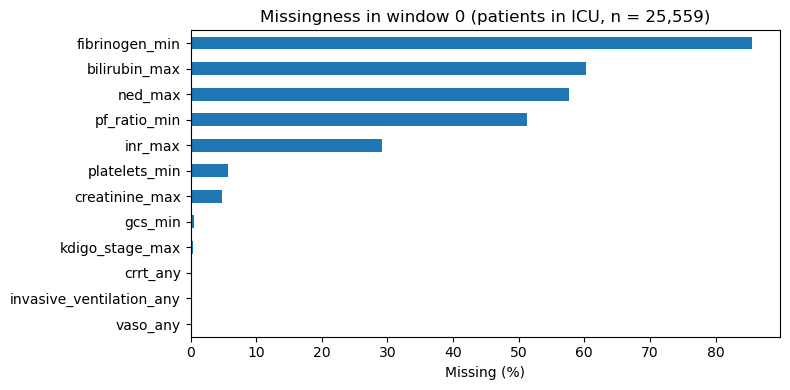

In [46]:
# plot the missingness in W0 for patients in ICU
fig, ax = plt.subplots(figsize=(8, 4))
missing_w0.mul(100).plot.barh(ax=ax)
ax.set_xlabel('Missing (%)')
ax.set_title('Missingness in window 0 (patients in ICU, n = {:,})'.format(len(w0)))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

- ned_max missing means no use of vasoactive medication. Missing means 0.
- platelets、creatinine、gcs、kdigo: low missing rate (0.4 - 5.7%), likely to be missing error on random patients. Can use Median Imputation to fix.
- fibrinogen、bilirubin、P/F、INR: high missing rate (29 -86%), because these tests/treatments are done only when DR requested to check specific conditions.  Cannot use Median Imputation as they were not routine check for every patients.

In [47]:
print(w0[['pf_ratio_min', 'bilirubin_max', 'inr_max', 'fibrinogen_min']].median())

pf_ratio_min      198.0
bilirubin_max       0.9
inr_max             1.3
fibrinogen_min    250.0
dtype: float64


- Among patients with a measurement, the median P/F ratio was 198, equivalent to moderate respiratory
  failure. Missing values for tests ordered on clinical suspicion were instead imputed with a normal value (missing = not clinically suspected).
- use Normal-value Imputation to handle missing value in these 4 variables.


In [48]:
# feature engineering for model input: fill missing values according to clinical knowledge and assumptions
df_model = df_features.copy()

# fill missing values for vasoactive dose (NED) with 0, as NULL = no use in window
df_model['ned_max'] = df_model['ned_max'].fillna(0)

# fill implausible values or missing values (bilirubin, INR, P/F, fibrinogen) with mid-normal values
NORMAL_FILL = {
    'bilirubin_max':  0.7,    # mg/dL, normal 0.2–1.2
    'inr_max':        1.0,    # normal 0.8–1.2
    'pf_ratio_min':   450,    # normal 400–500
    'fibrinogen_min': 300,    # mg/dL, normal 200–400
}
df_model = df_model.fillna(NORMAL_FILL)

# remaining missing values (creatinine, platelets, KDIGO, GCS) are imputed with the median inside the pipeline
print(df_model[FEATURES].isna().mean().round(3))

creatinine_max              0.120
bilirubin_max               0.000
inr_max                     0.000
fibrinogen_min              0.000
platelets_min               0.131
pf_ratio_min                0.000
kdigo_stage_max             0.294
gcs_min                     0.306
crrt_any                    0.000
invasive_ventilation_any    0.000
vaso_any                    0.000
ned_max                     0.000
dtype: float64


### Step 4. Clustering with k-means

In [49]:
# W0 feature matrix
m = df_model.merge(df_status[['stay_id', 'window_no', 'status']], on=['stay_id', 'window_no'])
w0_model = m[(m['window_no'] == 0) & (m['status'] == 'in_icu')].reset_index(drop=True)

X_w0 = w0_model[FEATURES]
print(X_w0.shape)    

(25559, 12)


In [50]:
# check the skewness of each feature in W0
print(X_w0.skew().sort_values(ascending=False).round(2))
X_w0 = w0_model[FEATURES].astype(float)

bilirubin_max               7.81
inr_max                     6.92
crrt_any                    6.79
ned_max                     6.51
creatinine_max              4.01
fibrinogen_min              3.38
platelets_min               1.67
kdigo_stage_max             0.33
vaso_any                    0.29
invasive_ventilation_any   -0.08
pf_ratio_min               -0.62
gcs_min                    -2.29
dtype: Float64


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.cluster import KMeans

RANDOM_STATE = 42    # fixed random seeds 
# right-skewed continuous features (skewness > 1): log1p to reduce the influence of extreme values 
LOG_COLS = ['bilirubin_max', 'inr_max', 'ned_max', 'creatinine_max',
            'fibrinogen_min', 'platelets_min']
# remaining features are not log-transformed: 
# binary (CRRT, ventilation, vasopressor),
# ordinal (KDIGO stage, GCS) 
# not right-skewed (P/F ratio)
OTHER_COLS = [c for c in FEATURES if c not in LOG_COLS]

# function to create a pipeline for preprocessing and KMeans clustering
def make_pipeline(k):
    
    preprocess = ColumnTransformer([
        # log-transformed variables: median imputation + log1p transformation
        ('log', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('log1p', FunctionTransformer(np.log1p)),
        ]), LOG_COLS),
        # other variables: only median imputation
        ('other', SimpleImputer(strategy='median'), OTHER_COLS),
    ])
    return Pipeline([
        ('preprocess', preprocess),
        ('scale', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)),
    ])

In [52]:
pipe = make_pipeline(3)          # k=3  pipeline
pipe.fit(X_w0)                   # use W0 data to fit
print(pipe.named_steps['kmeans'].inertia_)

230574.43741067842


In [53]:
K_RANGE = range(2, 11)     # iterate k=2, 3, ..., 10
inertias = []              
# run KMeans for each k and store the inertia
for k in K_RANGE:
    pipe = make_pipeline(k)
    pipe.fit(X_w0)
    inertias.append(pipe.named_steps['kmeans'].inertia_)
    print(f"k={k}: inertia={inertias[-1]:.0f}")

k=2: inertia=260132
k=3: inertia=230574
k=4: inertia=207018
k=5: inertia=191978
k=6: inertia=179696
k=7: inertia=169890
k=8: inertia=161158
k=9: inertia=153614
k=10: inertia=146398


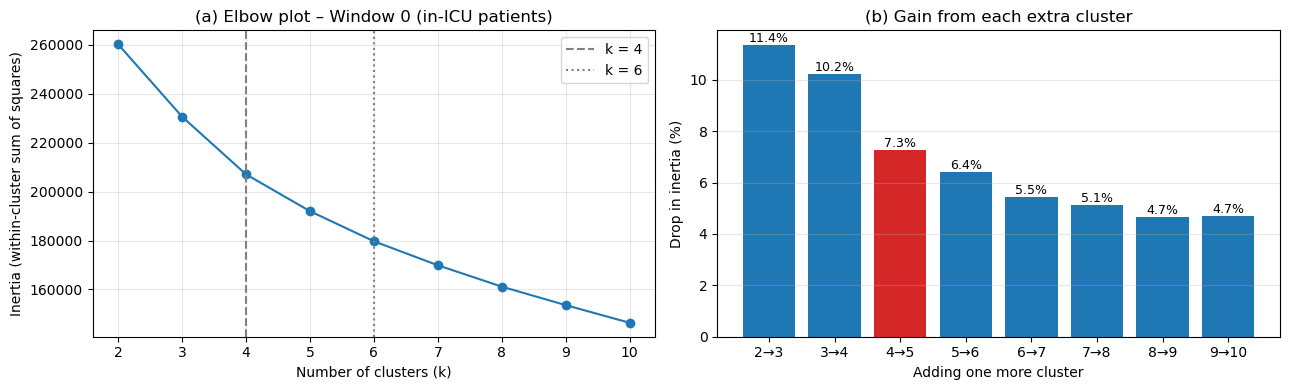

In [54]:
import matplotlib.pyplot as plt
import numpy as np

k_list = list(K_RANGE)

# % drop in inertia when adding one more cluster (e.g. the value at k=3 is the drop from k=2 to k=3)
pct_drop = -np.diff(inertias) / np.array(inertias[:-1]) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Elbow plot, with the two chosen k marked
axes[0].plot(k_list, inertias, marker='o')
for k, style in [(4, '--'), (6, ':')]:
    axes[0].axvline(k, color='grey', linestyle=style, label=f'k = {k}')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('(a) Elbow plot – Window 0 (in-ICU patients)')
axes[0].set_xticks(k_list)
axes[0].grid(alpha=0.3)
axes[0].legend()

# (b) % drop in inertia for each extra cluster
labels = [f'{k-1}→{k}' for k in k_list[1:]]
colors = ['tab:red' if lab == '4→5' else 'tab:blue' for lab in labels]
bars = axes[1].bar(labels, pct_drop, color=colors)
axes[1].bar_label(bars, fmt='%.1f%%', fontsize=9)
axes[1].set_xlabel('Adding one more cluster')
axes[1].set_ylabel('Drop in inertia (%)')
axes[1].set_title('(b) Gain from each extra cluster')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

| Clusters added (k → k+1) | Drop in inertia (%) | Change from previous drop (percentage points) |
|---|---|---|
| 2 → 3 | 11.4% | – |
| 3 → 4 | 10.2% | −1.2 |
| **4 → 5** | **7.3%** | **−2.9 (largest change)** |
| 5 → 6 | 6.4% | −0.9 |
| 6 → 7 | 5.5% | −0.9 |
| 7 → 8 | 5.1% | −0.4 |
| 8 → 9 | 4.7% | −0.4 |
| 9 → 10 | 4.7% | 0.0 |


## **Q2. k-means clustering and choice of k**

K-means clustering was fitted on the Window 0 data of all 25,559 patients in the ICU at sepsis onset, for k from 2 to 10. Each k was run with 10 random initialisations (n_init = 10) to reduce the risk of a poor local solution, and random_state = 42 was fixed for reproducibility. The inertia is shown in the elbow plot above.

Because inertia always decreases as k increases, the lowest inertia cannot be used to choose k. Instead, the elbow method looks for the point after which extra clusters give clearly smaller improvements. The curve showed no sharp elbow, which is common for clinical data as patients lie on a continuum of severity.

To locate the elbow, the relative drop in inertia for each extra cluster was compared. Increasing k from 2 to 3 and from 3 to 4 reduced inertia by a similar amount (11.4% and 10.2%, difference of 1.2 percentage points), but the gain fell the most when k increased from 4 to 5 (10.2% and 7.3%, difference of 2.9 percentage points). The bend is identified at k = 4, as it is the point that additional clusters give smaller drops. Thus, k = 4 was chosen as the main solution.

Since the elbow is a heuristic and the bend was not sharp, a second value was also examined. k = 6 was chosen as a secondary solution because it lies after the elbow but before the curve flattens. This allowed a check on whether finer subgroups appear. Values above 6 were not considered, as each extra cluster reduced inertia by only about 5%. It will only add complexity to the model with little improvement.

In [55]:
# select k=4 and k=6 for further analysis
K_MAIN = 4
K_ALT = 6
# fit KMeans with k=4 and k=6 on W0 data
pipe_k4 = make_pipeline(K_MAIN).fit(X_w0)
pipe_k6 = make_pipeline(K_ALT).fit(X_w0)

w0_model['cluster_k4'] = pipe_k4.named_steps['kmeans'].labels_
w0_model['cluster_k6'] = pipe_k6.named_steps['kmeans'].labels_

print(w0_model['cluster_k4'].value_counts().sort_index())
print(w0_model['cluster_k6'].value_counts().sort_index())

cluster_k4
0    12683
1      521
2    10084
3     2271
Name: count, dtype: int64
cluster_k6
0      521
1     1885
2    10081
3     4554
4     1861
5     6657
Name: count, dtype: int64


In [56]:
# function to calculate the median (for continuous) or mean (for binary) of each feature in each cluster
CONT = ['creatinine_max', 'bilirubin_max', 'inr_max', 'fibrinogen_min',
        'platelets_min', 'pf_ratio_min', 'kdigo_stage_max', 'gcs_min', 'ned_max']
BIN = ['crrt_any', 'invasive_ventilation_any', 'vaso_any']

# W0 feature matrix for cluster profiling: convert all features to float, fill missing NED with 0
raw_w0 = df_features[df_features['window_no'] == 0][['stay_id'] + FEATURES].copy()
raw_w0[FEATURES] = raw_w0[FEATURES].astype(float)
raw_w0['ned_max'] = raw_w0['ned_max'].fillna(0)

# merge cluster labels with raw W0 features for profiling
prof = w0_model[['stay_id', 'cluster_k4', 'cluster_k6']].merge(raw_w0, on='stay_id')

# function to calculate the median (for continuous) or mean (for binary) of each feature in each cluster
def cluster_profile(df, cluster_col):
    agg = {c: 'median' for c in CONT}
    agg.update({c: 'mean' for c in BIN})
    out = df.groupby(cluster_col).agg(agg)
    out.insert(0, 'n', df[cluster_col].value_counts().sort_index())
    return out.round(2)

profile_k4 = cluster_profile(prof, 'cluster_k4')
profile_k6 = cluster_profile(prof, 'cluster_k6')
display(profile_k4)
display(profile_k6)

# k=4 and k=6 cluster comparison: cross-tabulation of cluster membership
display(pd.crosstab(prof['cluster_k4'], prof['cluster_k6']))

,n,creatinine_max,bilirubin_max,inr_max,fibrinogen_min,platelets_min,pf_ratio_min,kdigo_stage_max,gcs_min,ned_max,crrt_any,invasive_ventilation_any,vaso_any
cluster_k4,,,,,,,,,,,,,
0,12683,1.0,0.7,1.3,394.5,183.0,332.50,0.0,14.0,0.00,0.0,0.16,0.15
1,521,3.8,1.9,1.8,192.0,117.0,143.08,3.0,15.0,0.30,1.0,0.78,0.79
2,10084,1.0,0.7,1.3,307.0,163.0,193.33,1.0,15.0,0.09,0.0,0.96,0.72
3,2271,1.7,4.4,2.2,156.0,77.0,178.00,2.0,15.0,0.10,0.0,0.55,0.59


,n,creatinine_max,bilirubin_max,inr_max,fibrinogen_min,platelets_min,pf_ratio_min,kdigo_stage_max,gcs_min,ned_max,crrt_any,invasive_ventilation_any,vaso_any
cluster_k6,,,,,,,,,,,,,
0,521,3.8,1.9,1.8,192.0,117.0,143.08,3.0,15.0,0.30,1.0,0.78,0.79
1,1885,1.0,0.6,1.3,268.0,173.0,202.00,1.0,6.0,0.03,0.0,0.77,0.54
2,10081,1.1,0.7,1.3,417.0,183.0,280.00,0.0,14.0,0.00,0.0,0.00,0.18
3,4554,0.9,0.6,1.2,314.0,175.0,202.50,1.0,15.0,0.00,0.0,0.93,0.00
4,1861,1.7,5.2,2.2,150.0,73.0,177.14,2.0,15.0,0.07,0.0,0.51,0.56
5,6657,1.0,0.7,1.3,292.5,156.0,194.00,1.0,15.0,0.15,0.0,0.93,1.00


cluster_k6,0,1,2,3,4,5
cluster_k4,,,,,,
0,0,625,10012,1974,1,71
1,521,0,0,0,0,0
2,0,1157,2,2532,0,6393
3,0,103,67,48,1860,193


**Cluster characteristics and naming(k = 4)**
- **0 – Mild:** near-normal labs (creatinine 1.0, bilirubin 0.7, platelets 183), highest P/F (332), KDIGO 0, and few needed organ support (ventilation 16%, vasopressors 15%)
- **1 – Renal / CRRT:** all on CRRT (100%), with the highest creatinine (3.8) and KDIGO stage (3)
- **2 – Cardiorespiratory:** labs similar to Mild, but most were ventilated (96%) and on vasopressors (72%), with relative low P/F (193)
- **3 – Hepatic–coagulopathic:** highest bilirubin (4.4) and INR (2.2), lowest platelets (77) and fibrinogen (156)

- Note: GCS was not used for cluster diffrences analysis, as medians were similar across clusters (14–15). Also, mild patients subgroup had a slightly lower median GCS (14) than sicker clusters (15), because unassessable patients (e.g. sedated or ventilated), are recorded as 15.

**k = 6 clusters**
- **0 – Renal / CRRT (n = 521):** identical to the k = 4 Renal / CRRT cluster. All on CRRT, highest creatinine (3.8) and KDIGO stage (3)
- **1 – Neurological (n = 1,885):** new cluster, median GCS 6. The only cluster defined by GCS with other labs near normal.
- **2 – Mild (n = 10,081):** almost the same as the k = 4 Mild cluster, but with no ventilated patients (0%)
- **3 – Ventilated, no vasopressors (n = 4,554):** ventilation 93%, vasopressors 0%
- **4 – Hepatic–coagulopathic (n = 1,861):** mostly from the same k = 4 cluster (1,860 of 2,271). Highest bilirubin (5.2) and INR (2.2), lowest platelets (73) and fibrinogen (150)
- **5 – Ventilated with vasopressors (n = 6,657):** ventilation 93%, vasopressors 100%

- **Summary:** the CRRT and hepatic clusters were stable, while the k = 4 Cardiorespiratory cluster was split by vasopressor use (3 and 5). The extra clusters mainly followed combinations of binary variables, so they reflect treatment patterns more than new phenotypes.

In [57]:
# merge cluster labels with outcome data for each patient
prof_out = prof.merge(
    df_outcome[['stay_id', 'in_hospital_mortality', 'icu_los_days', 'hospital_los_days']],
    on='stay_id', how='left'
)
# function to calculate the number of patients, mortality rate, and median ICU and hospital LOS for each cluster
def outcome_table(df, cluster_col):
    return df.groupby(cluster_col).agg(
        n=('stay_id', 'size'),
        mortality=('in_hospital_mortality', 'mean'),
        icu_los_median=('icu_los_days', 'median'),
        hosp_los_median=('hospital_los_days', 'median'),
    ).round(2)

display(outcome_table(prof_out, 'cluster_k4'))
display(outcome_table(prof_out, 'cluster_k6'))

,n,mortality,icu_los_median,hosp_los_median
cluster_k4,,,,
0,12683,0.1,2.18,7.66
1,521,0.46,5.80,13.90
2,10084,0.16,3.70,9.08
3,2271,0.39,3.62,11.08


,n,mortality,icu_los_median,hosp_los_median
cluster_k6,,,,
0,521,0.46,5.80,13.90
1,1885,0.26,4.11,9.78
2,10081,0.09,2.00,7.33
3,4554,0.11,3.60,9.18
4,1861,0.39,3.60,10.96
5,6657,0.17,3.45,8.96


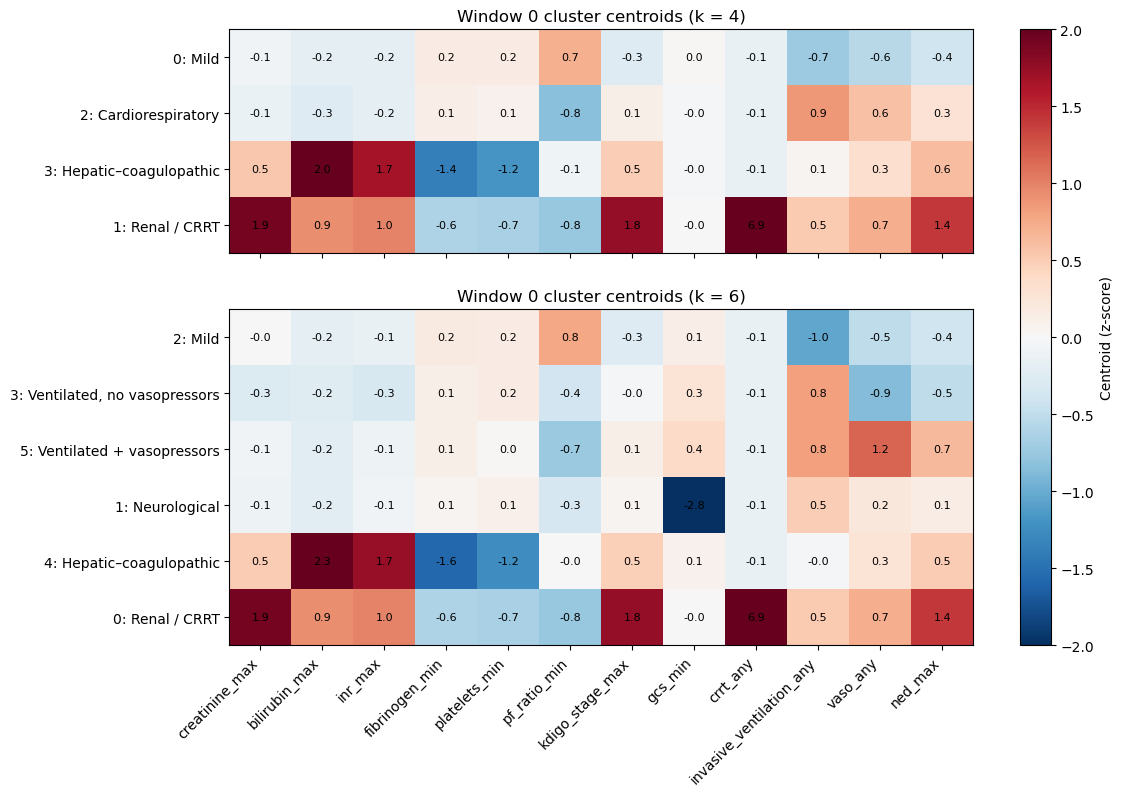

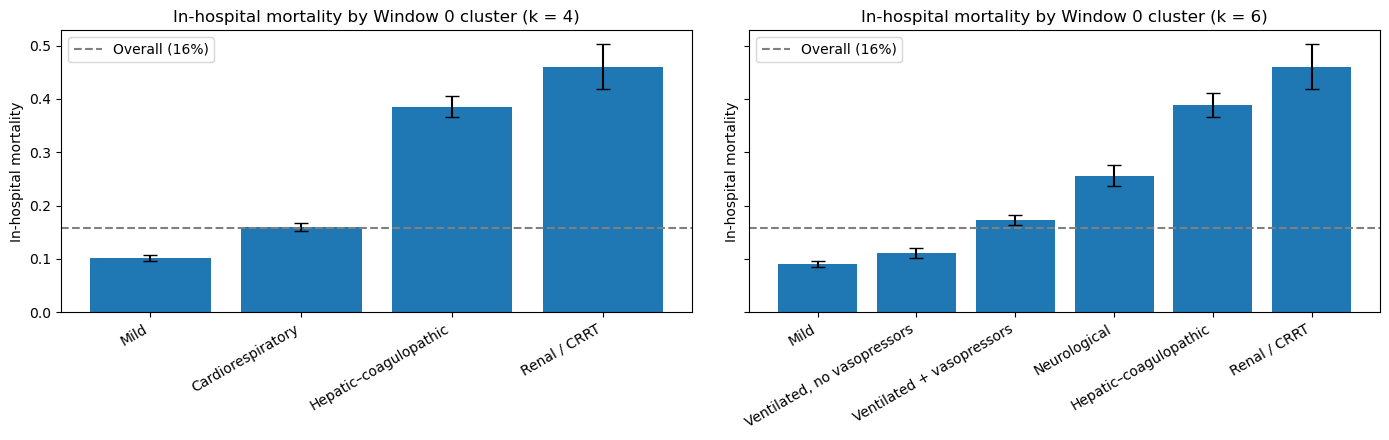

In [58]:
# cluster names and display order (ordered by in-hospital mortality, low to high)
K4_NAMES = {0: 'Mild', 1: 'Renal / CRRT', 2: 'Cardiorespiratory', 3: 'Hepatic–coagulopathic'}
K4_ORDER = [0, 2, 3, 1]
K6_NAMES = {0: 'Renal / CRRT', 1: 'Neurological', 2: 'Mild',
            3: 'Ventilated, no vasopressors', 4: 'Hepatic–coagulopathic', 5: 'Ventilated + vasopressors'}
K6_ORDER = [2, 3, 5, 1, 4, 0]


def plot_centroids(pipe, names, order, k, ax):
    """Heatmap of cluster centroids (z-scores in the standardised feature space)."""
    # ColumnTransformer outputs LOG_COLS first, then OTHER_COLS → rename, then reorder to FEATURES
    centers = pd.DataFrame(pipe.named_steps['kmeans'].cluster_centers_,
                           columns=LOG_COLS + OTHER_COLS)[FEATURES].loc[order]
    im = ax.imshow(centers.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels(FEATURES, rotation=45, ha='right')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([f"{c}: {names[c]}" for c in order])
    for i in range(centers.shape[0]):
        for j in range(centers.shape[1]):
            ax.text(j, i, f"{centers.iloc[i, j]:.1f}", ha='center', va='center', fontsize=8)
    ax.set_title(f'Window 0 cluster centroids (k = {k})')
    return im


def plot_mortality(df, cluster_col, names, order, k, ax):
    """In-hospital mortality by cluster with 95% CI (normal approximation)."""
    mort = df.groupby(cluster_col)['in_hospital_mortality'].agg(['mean', 'size']).loc[order]
    ci = 1.96 * np.sqrt(mort['mean'] * (1 - mort['mean']) / mort['size'])
    overall = df['in_hospital_mortality'].mean()
    ax.bar([names[c] for c in order], mort['mean'], yerr=ci, capsize=5)
    ax.axhline(overall, linestyle='--', color='grey', label=f'Overall ({overall:.0%})')
    ax.set_ylabel('In-hospital mortality')
    ax.set_title(f'In-hospital mortality by Window 0 cluster (k = {k})')
    ax.tick_params(axis='x', rotation=30)
    ax.legend()


# Figure 1: centroid heatmaps (k = 4 on top, k = 6 below)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [4, 6]})
im = plot_centroids(pipe_k4, K4_NAMES, K4_ORDER, 4, axes[0])
plot_centroids(pipe_k6, K6_NAMES, K6_ORDER, 6, axes[1])
axes[0].set_xticklabels([])                       # only show variable names on the bottom heatmap
fig.colorbar(im, ax=axes, label='Centroid (z-score)')
plt.show()

# Figure 2: mortality bar charts (k = 4 left, k = 6 right), same y-axis for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
plot_mortality(prof_out, 'cluster_k4', K4_NAMES, K4_ORDER, 4, axes[0])
plot_mortality(prof_out, 'cluster_k6', K6_NAMES, K6_ORDER, 6, axes[1])
for ax in axes:
    plt.setp(ax.get_xticklabels(), ha='right')
plt.tight_layout()
plt.show()

## **Q3. Cluster differences and patients outcomes**
When k = 4, the four clusters differed mainly in their pattern of organ failure, as shown in the centroid heatmap. The Mild cluster had near-normal lab values and the highest P/F ratio, with little organ support such as invasive ventilation or vasopressors. The Cardiorespiratory cluster had normal labs but the highest ventilation rate (96%), frequent vasopressor use (72%) and a low P/F ratio. The Hepatic–coagulopathic cluster had the highest bilirubin and INR and the lowest fibrinogen and platelets. The Renal / CRRT cluster was defined by CRRT with high creatinine and KDIGO stage.

These differences were strongly related to outcomes. In-hospital mortality rose from 10% (Mild) and 16% (Cardiorespiratory) to 39% (Hepatic–coagulopathic) and 46% (Renal / CRRT), with non-overlapping confidence intervals for most clusters. Therefore, patients with liver and coagulation failure carried a much higher risk of death than others.

At k = 6, the Renal / CRRT and Hepatic–coagulopathic clusters were mostly overlapped. Ventilated patients were split by vasopressor use, with higher mortality in those receiving vasopressors (17% vs 11%). A new Neurological cluster with very low GCS (median 6) appeared, with a mortality of 26%, higher than the overall rate (16%).

In [59]:
# apply the W0 pipeline to all windows for patients who are in ICU, and assign cluster labels and states
m_all = df_model.merge(df_status[['stay_id', 'window_no', 'status']],
                       on=['stay_id', 'window_no'])

in_icu = m_all['status'] == 'in_icu'

# die or leave ICU patients: assign state based on status
m_all['state'] = m_all['status'].map({'died': 'Died', 'out_icu': 'Left ICU'})

# in-ICU patients: assign state based on cluster labels from W0 pipeline
m_all.loc[in_icu, 'cluster'] = pipe_k4.predict(m_all.loc[in_icu, FEATURES].astype(float))
m_all.loc[in_icu, 'state'] = m_all.loc[in_icu, 'cluster'].astype(int).map(K4_NAMES)

# check that the W0 cluster labels match the original W0 labels
w0_check = m_all[(m_all['window_no'] == 0) & in_icu].merge(w0_model[['stay_id', 'cluster_k4']], on='stay_id')
assert (w0_check['cluster'] == w0_check['cluster_k4']).all(), "W0 labels do not match"
assert m_all['state'].notna().all(), "Some rows have no state"
print("All windows labelled:", m_all.shape)

All windows labelled: (102280, 17)


In [60]:
# check the number of patients in each state at each window
STATE_ORDER = [K4_NAMES[k] for k in K4_ORDER] + ['Left ICU', 'Died']

counts = pd.crosstab(m_all['window_no'], m_all['state'])[STATE_ORDER]
counts['In ICU (total)'] = counts[[K4_NAMES[k] for k in K4_ORDER]].sum(axis=1)
display(counts)

state,Mild,Cardiorespiratory,Hepatic–coagulopathic,Renal / CRRT,Left ICU,Died,In ICU (total)
window_no,,,,,,,
0,12683,10084,2271,521,4,7,25559
1,14249,5015,1489,654,3632,531,21407
2,9894,3677,1055,706,9238,1000,15332
3,7064,2895,763,673,12841,1334,11395


In [61]:
import plotly.graph_objects as go

# Sankey diagram: W0 cluster → W3 state
wide = m_all.pivot(index='stay_id', columns='window_no', values='state')

# only keep patients who were in ICU at W0 (i.e. have a W0 cluster label)
wide = wide[wide[0].isin(K4_NAMES.values())]

flows = wide.groupby([0, 3]).size().reset_index(name='n')

# node labels: W0 clusters (left) and W3 states (right), with counts in parentheses
left  = [K4_NAMES[k] for k in K4_ORDER]
right = STATE_ORDER
n_left  = wide[0].value_counts()
n_right = wide[3].value_counts()
labels = [f"W0 {s} (n={n_left.get(s, 0):,})" for s in left] + \
         [f"W3 {s} (n={n_right.get(s, 0):,})" for s in right]

# plotly identifies nodes by index: left nodes are 0–3,
# right nodes are offset by len(left) so they do not overlap
src = flows[0].map({s: i for i, s in enumerate(left)})
tgt = flows[3].map({s: i + len(left) for i, s in enumerate(right)})
fig = go.Figure(go.Sankey(
    node=dict(label=labels, pad=15, thickness=15),
    link=dict(source=src, target=tgt, value=flows['n'])
))
fig.update_layout(title_text='Patient movement: Window 0 cluster → Window 3 state (k = 4)',
                  font_size=12, height=550)
fig.show()

In [62]:
# transition matrix: W0 cluster → W3 state
transition = pd.crosstab(wide[0], wide[3], normalize='index').loc[left, right].round(3)
display(transition)

3,Mild,Cardiorespiratory,Hepatic–coagulopathic,Renal / CRRT,Left ICU,Died
0,,,,,,
Mild,0.276,0.042,0.007,0.005,0.644,0.026
Cardiorespiratory,0.311,0.215,0.012,0.017,0.392,0.053
Hepatic–coagulopathic,0.164,0.077,0.236,0.077,0.295,0.151
Renal / CRRT,0.098,0.048,0.033,0.495,0.090,0.236


## **Q4. Movement between Window 0 and Window 3 (k = 4)**

The number of patients in the ICU fell from 25,559 at Window 0 to 21,407, 15,332 and 11,395 at Windows 1, 2 and 3. By Window 3, 12,841 patients had left the ICU alive and 1,334 had died.

The Sankey diagram shows that patients did not evolve in the same way, and their outcome depended on the initial cluster in Window 0. Most Mild patients left the ICU (64%), 28% remained mild and only 3% died by Window 3. The Cardiorespiratory cluster improved the most with 39% leaving the ICU and 31% changing to Mild, while 5% died. The Hepatic–coagulopathic cluster is the most unpredictable group, with 30% leaving ICU, 24% unchanged, 15% dying and 8% progressing to Renal / CRRT cluster. Lastly, the Renal / CRRT cluster was the most persistent with 50% remained unchanged, 24% dead and only 9% leaving the ICU. 

Overall, milder clusters mostly recovered and left, and severe clusters persisted or died, matching the mortality gradient in Q3. The Renal / CRRT cluster also grew from 521 to 673, suggesting that some patients developed renal failure after sepsis onset. As a result, patients remaining at Window 3 were a more selected and sicker group that CRRT use rising from 2% to 6% in ICU patients.

### **References**

[1] H. Harutyunyan, H. Khachatrian, D. C. Kale, G. Ver Steeg, and A. Galstyan, "Multitask learning and benchmarking with clinical time series data," *Sci. Data*, vol. 6, no. 1, Art. no. 96, 2019, doi: 10.1038/s41597-019-0103-9.

[2] E. Moritz *et al.*, "Notes from the field: Outbreak of severe illness linked to the vitamin K antagonist brodifacoum and use of synthetic cannabinoids — Illinois, March–April 2018," *MMWR Morb. Mortal. Wkly. Rep.*, vol. 67, no. 21, pp. 607–608, 2018. [Online]. Available: https://www.cdc.gov/mmwr/volumes/67/wr/mm6721a4.htm

[3] S. S. Acharya, "Inherited abnormalities of fibrinogen," Medscape Reference, 2023. [Online]. Available: https://emedicine.medscape.com/article/960286-overview (accessed Sep. 27, 2026).

[4] E. Bassi, M. Park, and L. C. P. Azevedo, "Therapeutic strategies for high-dose vasopressor-dependent shock," *Crit. Care Res. Pract.*, vol. 2013, Art. no. 654708, 2013, doi: 10.1155/2013/654708.

### GenAI Declaration
I acknowledge the use of Claude and ChatGPT to give advice on rephrasing paragraph and correcting grammar,
to debug coding errors, and to fix Markdown formatting. All
study design decisions, cluster interpretations, clinical reasoning and final code are my own. A full record of prompts and outputs is available upon request.
